#### <center>Université Paul Sabatier  2025-2026</center>
# Simulations stochastiques - TP5 : méthode de Monte-Carlo et modèle de Bernoulli.

In [2]:
%matplotlib inline
from matplotlib.pyplot import *
from math import *
from numpy import *
from numpy.random import *
from scipy.misc import *
from scipy.stats import *

## Exercice 1, basé sur l'exercice 2 du TD4
On considère l'intégrale suivante: 
$$I = \int_{0}^{\infty} e^{-x^2/2} dx.$$
On prend une suite $(X_k)_{k \geq 1}$ de variables exponentielles indépendantes de paramètre $1$,
et on pose $Y_k = e^{X_k - X_k^2/2}$, $I_n = (Y_1 + Y_2 + \dots + Y_n)/n$.
* 3) En TD, on a montré que pour $n$ suffisamment grand, $\mathbb{P} (I \in [I_n -2 \Sigma_n/\sqrt{n},I_n + 2 \Sigma_n/\sqrt{n}])$ est supérieur à $0.95$.

Rappel : $\displaystyle I=\sqrt{\frac{\pi}{2}}$ et $\displaystyle
\Sigma_n=\sqrt{\frac{1}{n}\left(\sum_{k=1}^n Y_k^2\right)-I_n^2}
=\sqrt{\frac{1}{n}\sum_{k=1}^n (Y_k-I_n)^2}$.
* 5) Simuler $N=10000$ fois
le calcul de l'intervalle donné dans 
(3), pour $n = 10000$, et déterminer
combien de fois $I$ tombe en dehors de 
cet intervalle aléatoire. Remarque : $N$ grand pour assurer un résultat significatif dans la LGN. 
$n$ grand pour que l'intervalle de confiance soit de longueur petite (et donc l'estimation de $I$ précise).

In [ ]:
N=10**4
n=10**4
...

## Exercice 2 : calcul du niveau effectif d'un intervalle de confaince dans le modèle de Bernoulli

Dans le modèle de Bernoulli (de taille $n$), on observe $x_1, \ldots, x_n$ les réalisations de v.a. i.i.d. $(X_i)_{i=1,\ldots, n}$ de loi de Bernoulli de paramètre $\theta$.

On cherche généralement à estimer $\theta$ à partir des observations, et pour cela l'estimateur utilisé est $\hat{\theta}_n = \frac{1}{n} \sum_{i=1}^n X_i$. On construit également des intervalles de confiance par différentes méthodes. Dans cet exercice nous chercherons à estimer (par Monte-Carlo) le niveau effectif $\Pr(\theta\in I_{BT})$ de l'intervalle de confiance basé sur l'inégalité de Bienaymé-Tchebychev
$$ I_{BT} = \left[ \hat{\theta}_n - \frac{1}{\sqrt{4 n \alpha}},\, \hat{\theta}_n + \frac{1}{\sqrt{4 n \alpha}} \right] $$

On sait que $\sum_{i=1}^n X_i$ suit une loi binomiale de paramètre $(n,\theta)$. Simuler une telle loi peut se faire avec la fonction `binomial` (un exemple est donné ci-dessous). Pour le TP, nous pourrons par exemple choisir `n = 30` et $\theta = 1/2$. Il faudra en revanche considérer un risque $\alpha$ suffisamment grand. Pour comprendre pourquoi, vous pourrez choisir $\alpha=5\%$, puis $\alpha = 40\%$ (ou même $\alpha = 50\%$).

In [2]:
n = 30
binomial(n,.5,10).astype(float) / n

array([0.46666667, 0.53333333, 0.4       , 0.56666667, 0.43333333,
       0.66666667, 0.6       , 0.23333333, 0.56666667, 0.43333333])

1. Écrire et tester successivement les fonctions suivantes d'arguments `n`, `p`, `theta`=$\theta$, et `alpha`=$\alpha$, 
   
   a) `proportionsempiriques(n, p, theta)`, qui simule et renvoie `p` réalisations aléatoires indépendants de $\hat{\theta}_n$ ;
   
   b) `intervallesBT(n, p, theta, alpha)`, qui représente les `p` réalisations aléatoires indépendantes de $I_{BT}$ associées côte à côte, en distinguant graphiquement les intervalles qui ne contiennent pas $\theta$ ; 
   
   

In [ ]:
#### Question a)



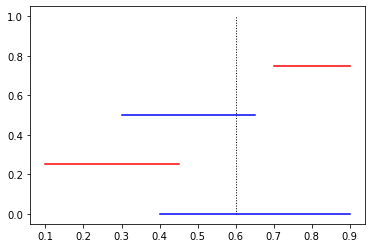

In [2]:
# Pour traiter la question b), la fonction suivante peut vous être utile.

def plotIntervalles(X, val):
    ## Dessine les intervalles donnés dans X (vu comme des lignes de X; X est une matrice p x 2, codant donc
    ##### p intervalles; il faut, pour tout i, X[i,0] <X[i,1]).
    ## En bleu ceux qui contiennent la valeur val, en rouge ceux qui ne la contiennent pas
    plot([val, val], [0,1], ':k', lw=1)
    for i in range(len(X)): ##### incrémente les lignes de X, i.e. les différents intervalles.
        if X[i][0] <= val <= X[i][1]:
            plot(X[i],[float(i) / len(X),float(i) / len(X)],'b') 
            # X[i] contient les deux extrémités du ieme intervalle 
# en ordonnée, un vecteur constant qui décale les intervalles vers le haut, suivant la subdivision adaptée de [0,1]  
        else:
            plot(X[i],[float(i) / len(X),float(i) / len(X)],'r')
## Exemple d'utilisation de plotIntervalles
XX = [[0.4,0.9], [0.1, 0.45], [0.3, 0.65], [0.7,0.9]]
vval=0.6
plotIntervalles(XX, vval)


In [ ]:
#### Question b)

def intervallesBT(n, p, theta, alpha):
    

   c) Ecrire maintenant une fonction `niveaueffectifBT(n, p, theta, alpha)`,  qui calcule et renvoie la proportion de ces intervalles $I_{BT}$ 
    parmi `p` qui ne contiennent pas $\theta$.

In [ ]:
def niveaueffectifBT(n, p, theta, alpha):
    return ...

2. Tester votre fonction `niveaueffectifBT` pour différentes valeurs des arguments. Observer et conclure.

   On étudiera en particulier le cas $n=30$, $p=10^4$, $\alpha=5\%$, et $\theta = 1/2$. 
   Et également 𝛼=40% (ou même 𝛼=50%). Pourquoi est-il pertinent de toujours prendre de grandes valeurs de `p` ?

## Exercice 3 : illustration de la LGN forte dans le modèle de Bernoulli

1. Expliquer pourquoi, si on veut illustrer la convergence presque sûre de $\hat{\theta}_n$ vers $\theta$, on ne peut pas simplement utiliser la fonction `binomial(n,...)` pour différentes valeurs successives de `n`.

2. Écrire une fonction `simuThetaHat(N, p, theta)` qui simule `p` trajectoires indépendantes de $\hat{\theta}_n$ pour `n` entre 1 et `N`. Le rendu devra être sous la forme d'un tableau à `p` lignes et `N` colonnes.

   Indication : simuler $p \times N$ tirages indépendants selon la loi de Bernoulli de paramètre $\theta=$`theta`, les placer dans un tableau, et utiliser des sommes cumulatives et des divisions sur les lignes.

3. Tester la fonction `simuThetaHat(N, p, theta)` de la question précédente, et en exploiter la sortie pour représenter graphiquement plusieurs trajectoires de la suite $(\hat{\theta}_n)_n$.

   On pourra éventuellement choisir `p` assez petit, et colorier différemment les trajectoires. En revanche `N` assez grand (`N=10**4` par exemple) aidera à visualiser le comportement asymptotique.

## Et un exercice corrigé : tests pour le modèle de Bernoulli

On se place dans le modèle de Bernoulli, où on rappelle qu'on observe un échantillon $X_1,X_2,\ldots,X_n \stackrel{\textrm{i.i.d.}}{\sim}{\cal B}(\theta)$ avec $\theta \in ]0,1[$ inconnu.  On considère les deux hypothèses :   $H_0: \theta \leq \theta_0$ et $H_1: \theta > \theta_0$.

L'objectif de l'exercice est de manipuler numériquement les tests du cours sur le paramètre $\theta$ qu'on a construits avec l'inégalité de Bienaymé-Tchebychev et avec le TCL ; on notera ces 2 tests $\phi_n^{BT}$ et $\phi_n^{TCL}$.

Les simulations seront réalisées avec différentes tailles d'échantillon $n$, et avec $\theta_0 = 0.4$ et $\alpha = 0.05$.
* 1) Rappeler les expressions des tests $\phi_n^{BT}$ et $\phi_n^{TCL}$ construits en cours avec l'inégalité de Bienaymé-Tchebychev et avec le TCL.

Réponse : $\phi_n=1_{\hat\theta_n>\theta_0+\Delta_\alpha}$, où $\displaystyle\hat\theta_n=\frac{X_1+\ldots+X_n}{n}$  
et $\displaystyle \Delta_\alpha=\frac{1}{\sqrt{4\alpha n}}$ pour $\phi_n^{BT}$,
$\displaystyle \Delta_\alpha=q_{1-\alpha}\sqrt{\frac{\theta_0(1-\theta_0)}{n}}$ pour $\phi_n^{TCL}$.
* 2) On prend $\theta=\theta_0=0.4$. Pour chaque valeur de $n \in \{3,10,100,1000\}$, simuler $N_{\textrm{sim}} = 10^4$ échantillons de taille $n$ et vérifier pour chaque échantillon si les tests $\phi_n^{BT}$ et $\phi_n^{TCL}$ conservent ou rejettent l'hypothèse $H_0$. En déduire une estimation $\hat{r}_1^{BT}$ et $\hat{r}_1^{TCL}$ de la probabilité $\mathbb{P}_{\theta_0}\bigl(\phi_n(X_1,\ldots,X_n)=1\bigr)$ pour chacun des deux tests.  
A quoi correspond cette probabilité ? A-t-on bien $\hat{r}_1^{BT/TCL} \lesssim \alpha$ comme attendu ? Est-ce vrai pour tout $n$ ?

In [3]:
th0=0.4 
th=th0 #### Cas où H0 est vérifiée : détermination du risque de première espèce effectif.
a=0.05
nn=[3,10,100,1000]
Nsim=10**4 # ou valeurs plus grandes !
for n in nn:
    r1BT=mean(binomial(n,th,Nsim)/n>th0+1/sqrt(4*n*a))
    r1TCL=mean(binomial(n,th,Nsim)/n>th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))
    ##### ppf = percent point function, determine les quantiles 
    print("n =",n,"donne r1BT =",r1BT,"et r1TCL =",r1TCL)

n = 3 donne r1BT = 0.0 et r1TCL = 0.0645
n = 10 donne r1BT = 0.0 et r1TCL = 0.0551
n = 100 donne r1BT = 0.0001 et r1TCL = 0.043
n = 1000 donne r1BT = 0.0 et r1TCL = 0.0498


* 3) On prend maintenant $\theta=0.45$. Effectuer le même type de simulations qu'à la question précédente et en déduire une estimation $\hat{r}_2^{BT}$ et $\hat{r}_2^{TCL}$ de la probabilité $\mathbb{P}_{\theta}\bigl(\phi_n(X_1,\ldots,X_n)=0\bigr)$ pour chacun des deux tests. En pratique, veut-on que cette probabilité soit grande ou petite ? Dans votre cas, quel test semble être le meilleur au vu de ce critère ? est-ce étonnant ?

In [4]:
th=0.45 #### Cas où H1 est vérifiée. Et theta assez loin de la limite theta0. Détermination du rique de deuxième
#### espèce effectif associé. Moins bon pour BT que pour TCL.
for n in nn:
    r2BT = mean(binomial(n,th,Nsim)/n <= th0+1/sqrt(4*n*a))
    r2TCL = mean(binomial(n,th,Nsim)/n <= th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))
    print("n =",n,"donne r2BT =",r2BT,"et r2TCL =",r2TCL)

n = 3 donne r2BT = 1.0 et r2TCL = 0.911
n = 10 donne r2BT = 1.0 et r2TCL = 0.9003
n = 100 donne r2BT = 0.9998 et r2TCL = 0.7605
n = 1000 donne r2BT = 0.9078 et r2TCL = 0.0637


In [5]:
# On a estimé ci-dessus le risque de seconde espèce du test relatif à la valeur 
#### alternative theta=0.45
# Pas étonnant que ce risque soit plus grand pour phi-BT car ce test est plus conservateur (région de rejet plus petite)
# Plus précisément :
print("n = ", n)
print("seuil de rejet pour phi-BT : ",th0+1/sqrt(4*n*a))
print("seuil de rejet pour phi-TCL : ",th0+norm.ppf(1-a)*sqrt(th0*(1-th0)/n))

n =  1000
seuil de rejet pour phi-BT :  0.47071067811865475
seuil de rejet pour phi-TCL :  0.4254819628165277
